In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import glob
import seaborn as sns

In [4]:
brbl = LinearSegmentedColormap.from_list('brbl', np.concatenate([matplotlib.colormaps["BrBG"](np.arange(0, 0.6, .1)), 
                matplotlib.colormaps["RdBu"](np.arange(0.5, 1.1, .1))]), N = 11)

### Compare original and shifted observed trends

Summary: there are very slight differences, but there doesn't appear to be any notable bias in the magnitude of trends between the original and shifted grids, both in terms of the absolute magnitude and standardized magnitude 

In [5]:
ds = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_1970-2019_5x5_p095_trend.nc")
ds_shift = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_1970-2019_5x5_shifted_p095_trend.nc")

In [6]:
ds.predictions

<xarray.DataArray 'predictions' (predictions: 5)> Size: 260B
array(['coeff', 'intercept', 'pval', 'coeff_ci_low', 'coeff_ci_high'],
      dtype='<U13')
Coordinates:
  * predictions  (predictions) <U13 260B 'coeff' 'intercept' ... 'coeff_ci_high'

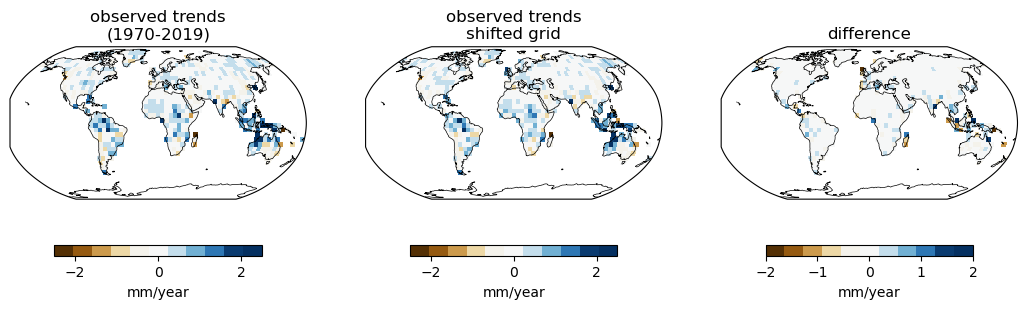

In [7]:
fig, axes = plt.subplots(1, 3, figsize = (13,4), subplot_kw={"projection": ccrs.Robinson()})

a = axes[0].pcolormesh(ds.lon, ds.lat, ds.sel(predictions = "coeff").value, vmin = -2.5, vmax = 2.5, cmap = brbl, 
                       transform = ccrs.PlateCarree())
b = axes[1].pcolormesh(ds.lon, ds.lat, ds_shift.sel(predictions = "coeff").value, vmin = -2.5, vmax = 2.5, cmap = brbl, 
                      transform = ccrs.PlateCarree())
c = axes[2].pcolormesh(ds.lon, ds.lat, (ds - ds_shift).sel(predictions = "coeff").value, vmin = -2, vmax = 2, cmap = brbl, 
                      transform = ccrs.PlateCarree())

plt.colorbar(a, ax = axes[0], shrink = 0.7, location = "bottom", label = "mm/year")
plt.colorbar(b, ax = axes[1], shrink = 0.7, location = "bottom", label = "mm/year")
plt.colorbar(c, ax = axes[2], shrink = 0.7, location = "bottom", label = "mm/year")

axes[0].set(title = "observed trends\n(1970-2019)")
axes[1].set(title = "observed trends\nshifted grid")
axes[2].set(title = "difference")

for i in range(3):
    axes[i].add_feature(cfeature.LAND.with_scale('110m'), facecolor = 'white')
    axes[i].add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)

In [8]:
sd = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_1970-2019_5x5_stats.nc")
sd_shift = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_1970-2019_5x5_shifted_stats.nc")

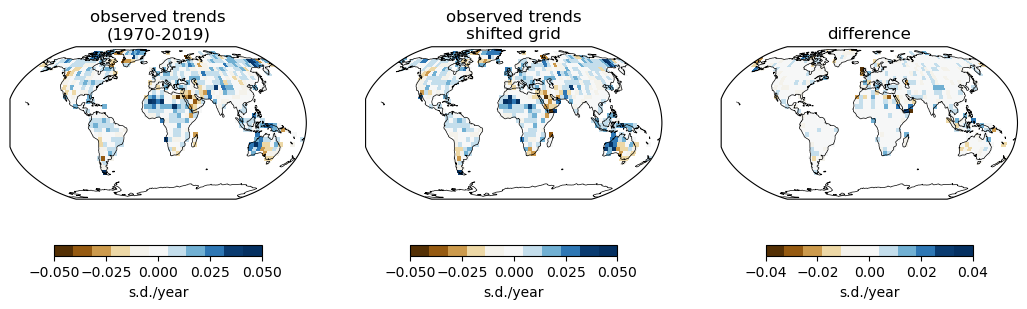

In [9]:
fig, axes = plt.subplots(1, 3, figsize = (13,4), subplot_kw={"projection": ccrs.Robinson()})

a = axes[0].pcolormesh(ds.lon, ds.lat, ds.sel(predictions = "coeff").value/sd.sd, vmin = -.05, vmax = .05, cmap = brbl, 
                       transform = ccrs.PlateCarree())
b = axes[1].pcolormesh(ds.lon, ds.lat, ds_shift.sel(predictions = "coeff").value/sd_shift.sd, vmin = -.05, vmax = .05, cmap = brbl, 
                      transform = ccrs.PlateCarree())
c = axes[2].pcolormesh(ds.lon, ds.lat, 
                       ds.sel(predictions = "coeff").value/sd.sd - ds_shift.sel(predictions="coeff").value/sd_shift.sd, 
                       vmin = -0.04, vmax = 0.04, cmap = brbl, 
                      transform = ccrs.PlateCarree())

plt.colorbar(a, ax = axes[0], shrink = 0.7, location = "bottom", label = "s.d./year")
plt.colorbar(b, ax = axes[1], shrink = 0.7, location = "bottom", label = "s.d./year")
plt.colorbar(c, ax = axes[2], shrink = 0.7, location = "bottom", label = "s.d./year")

for i in range(3):
    axes[i].add_feature(cfeature.LAND.with_scale('110m'), facecolor = 'white')
    axes[i].add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)

axes[0].set(title = "observed trends\n(1970-2019)")
axes[1].set(title = "observed trends\nshifted grid")
axes[2].set(title = "difference");

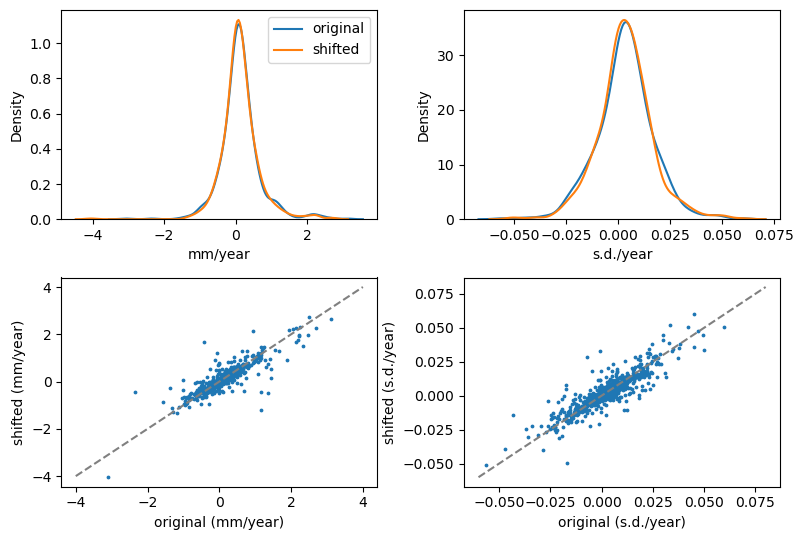

In [10]:
fig, axes = plt.subplots(2, 2, figsize = (8, 5.5))
sns.kdeplot(ds.sel(predictions = "coeff").value.values.reshape(-1), ax = axes[0,0], label = "original")
sns.kdeplot(ds_shift.sel(predictions = "coeff").value.values.reshape(-1), ax = axes[0,0], label = "shifted")

sns.kdeplot((ds.sel(predictions = "coeff").value/sd.sd).values.reshape(-1), ax = axes[0,1], label = "original")
sns.kdeplot((ds_shift.sel(predictions = "coeff").value/sd_shift.sd).values.reshape(-1), ax = axes[0,1], label = "shifted")

axes[0,0].legend();
axes[0,0].set(xlabel = "mm/year")
axes[0,1].set(xlabel = "s.d./year");

axes[1,0].scatter(ds.sel(predictions = "coeff").value.values.reshape(-1), 
            ds_shift.sel(predictions = "coeff").value.values.reshape(-1), s = 3)
axes[1,0].plot(np.arange(-4, 5), np.arange(-4, 5), linestyle = "--", c = "gray")

axes[1,1].scatter((ds.sel(predictions = "coeff").value/sd.sd).values.reshape(-1), 
            (ds_shift.sel(predictions = "coeff").value/sd_shift.sd).values.reshape(-1), s = 3)
axes[1,1].plot(np.arange(-0.06, 0.08, 0.01), np.arange(-0.06, 0.08, 0.01), linestyle = "--", c = "gray");
axes[1,0].set(ylabel = "shifted (mm/year)", xlabel = "original (mm/year)")
axes[1,1].set(ylabel = "shifted (s.d./year)", xlabel = "original (s.d./year)")
plt.tight_layout()

### Compare observed trends vs. climatological sd and quantiles

Summary: absolute trends are larger when the mean, s.d. or p95 are larger. Standardized trends are generally more uniform, or become slightly smaller as the s.d. or p95 increase (because standardizing by a larger unit). Both absolute and standardized trends appear to increase slightly as the skew increases (although not many locations have high skew).

In [11]:
y = ds.sel(predictions = "coeff").value.values.reshape(-1)
ystd = (ds.sel(predictions = "coeff").value/sd.sd).values.reshape(-1)

In [12]:
def loess_plot(x, y, ax):
    sns.regplot(x=x, y=y, 
            lowess=True, line_kws=dict(color="darkviolet"), scatter_kws=dict(color="gray", s = 3), ax = ax)
    return()

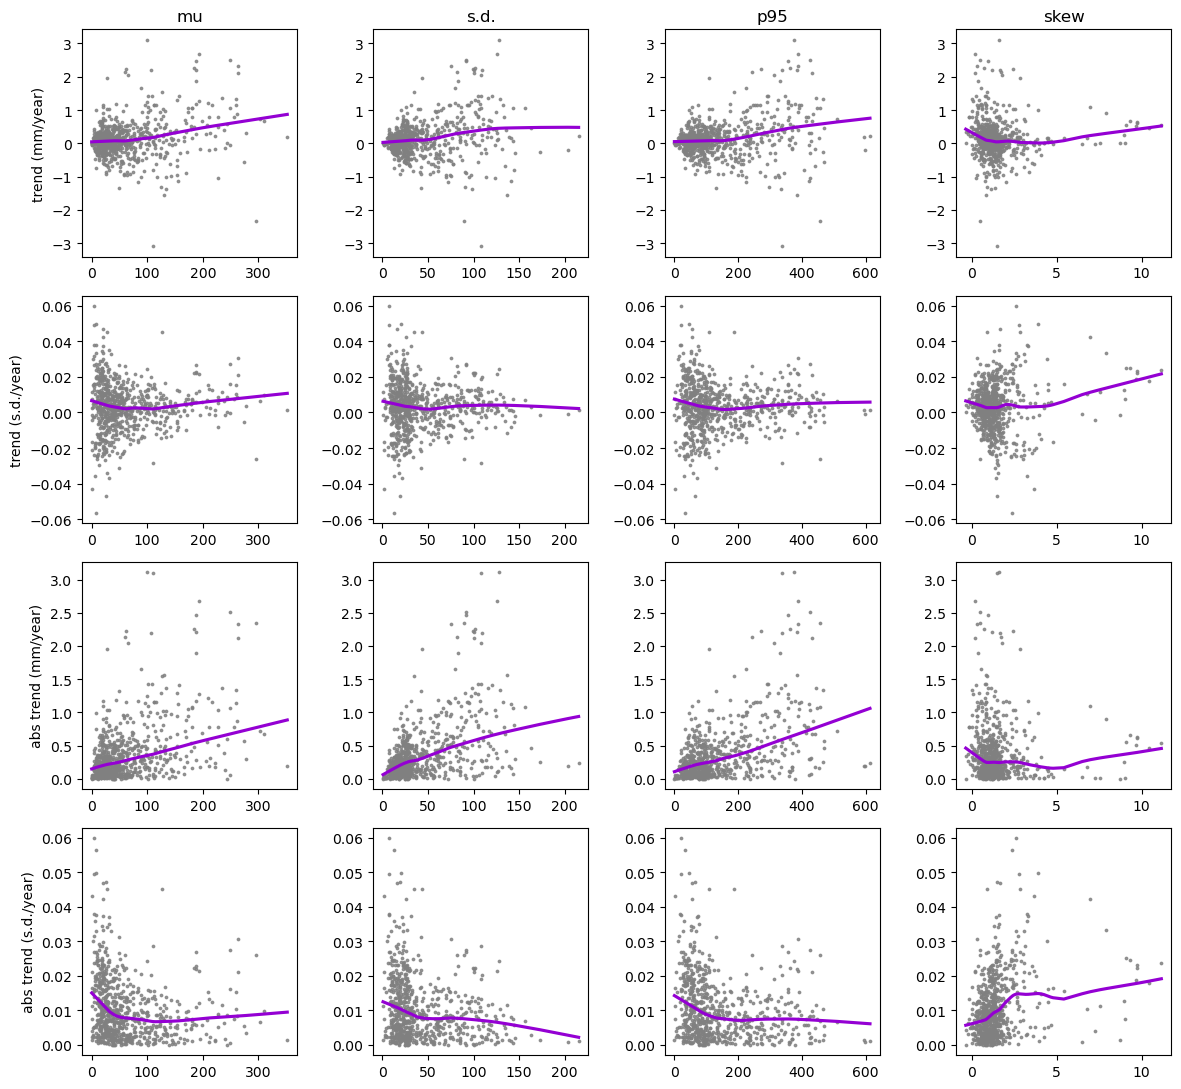

In [13]:
fig, axes = plt.subplots(4, 4, figsize = (12,11))

loess_plot(sd.mu.values.reshape(-1), y, axes[0,0])
loess_plot(sd.mu.values.reshape(-1), ystd, axes[1,0])
loess_plot(sd.mu.values.reshape(-1), np.abs(y), axes[2,0])
loess_plot(sd.mu.values.reshape(-1), np.abs(ystd), axes[3,0])

loess_plot(sd.sd.values.reshape(-1), y, axes[0,1])
loess_plot(sd.sd.values.reshape(-1), ystd, axes[1,1])
loess_plot(sd.sd.values.reshape(-1), np.abs(y), axes[2,1])
loess_plot(sd.sd.values.reshape(-1), np.abs(ystd), axes[3,1])

loess_plot(sd.p95.values.reshape(-1), y, axes[0,2])
loess_plot(sd.p95.values.reshape(-1), ystd, axes[1,2])
loess_plot(sd.p95.values.reshape(-1), np.abs(y), axes[2,2])
loess_plot(sd.p95.values.reshape(-1), np.abs(ystd), axes[3,2])

loess_plot(sd.skew.values.reshape(-1), y, axes[0,3])
loess_plot(sd.skew.values.reshape(-1), ystd, axes[1,3])
loess_plot(sd.skew.values.reshape(-1), np.abs(y), axes[2,3])
loess_plot(sd.skew.values.reshape(-1), np.abs(ystd), axes[3,3])

axes[0,0].set(title = "mu", ylabel = "trend (mm/year)")
axes[0,1].set(title = "s.d.")
axes[0,2].set(title = "p95")
axes[0,3].set(title = "skew")
axes[1,0].set(ylabel = "trend (s.d./year)")
axes[2,0].set(ylabel = "abs trend (mm/year)")
axes[3,0].set(ylabel = "abs trend (s.d./year)")

plt.tight_layout()

### Compare mean, s.d., and quantile thresholds between observations and models

In [14]:
files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_1970-2019_stats.nc"))

In [15]:
cmip_stat = []
for f in files:
    cmip_stat.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
cmip_stat = xr.concat(cmip_stat, dim = "model_variant")

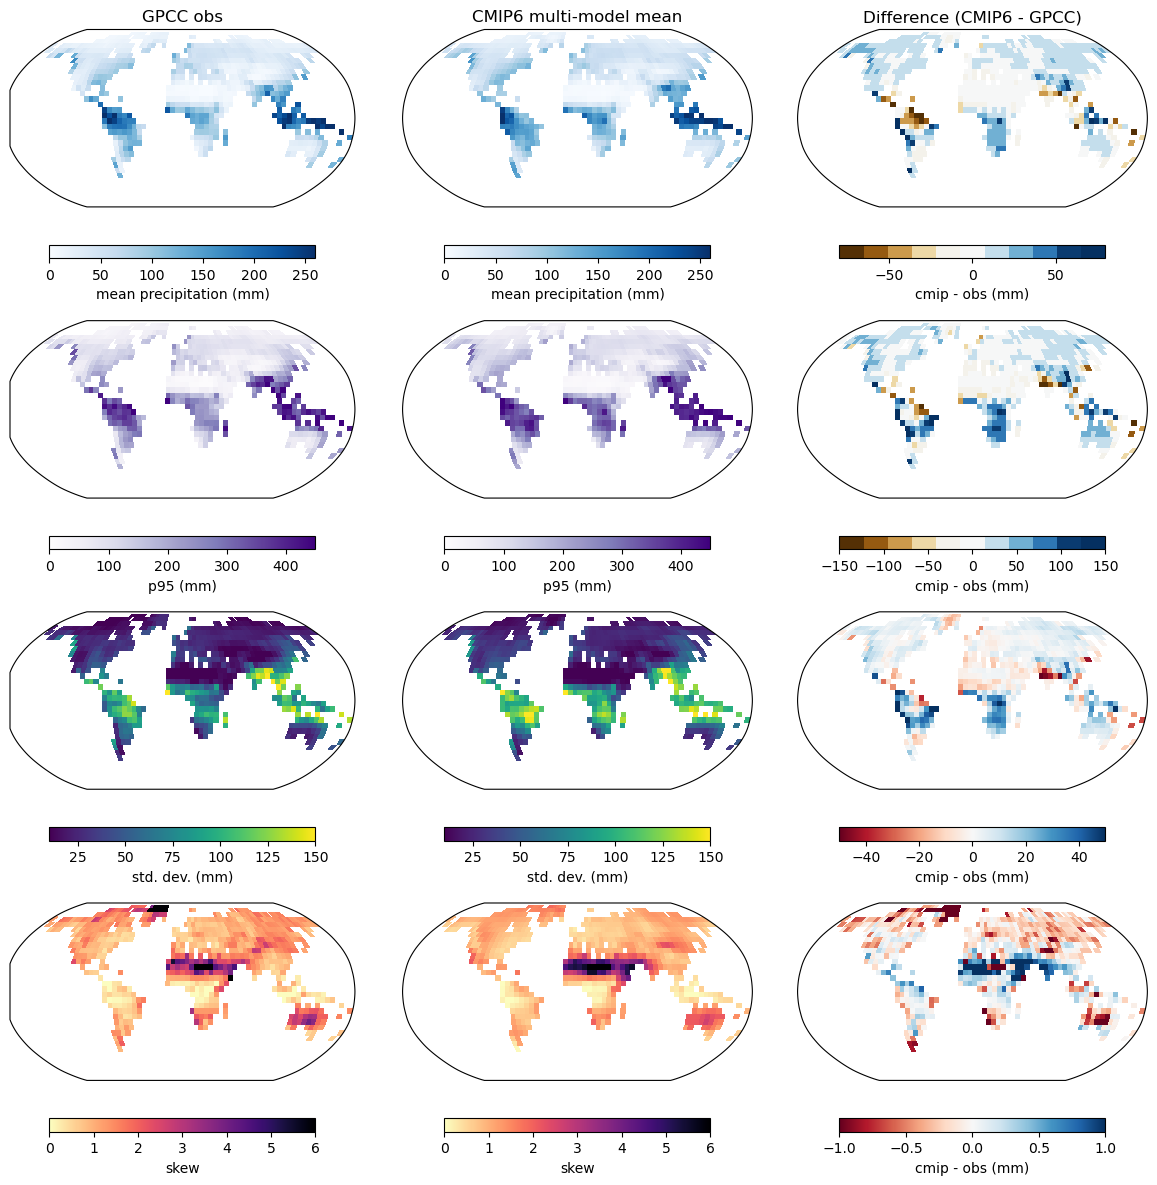

In [15]:
fig, axes = plt.subplots(4, 3, figsize = (12, 12), subplot_kw={"projection": ccrs.Robinson()})

## row 1
a = axes[0,0].pcolormesh(sd.lon, sd.lat, sd.mu, transform = ccrs.PlateCarree(), vmin = 0, vmax = 260, cmap = "Blues")
b = axes[0,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.mu.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 260, cmap = "Blues")
c = axes[0,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.mu.mean(dim = "model_variant")*86400*30 - sd.sel(lat = cmip_stat.lat).mu, 
                    transform = ccrs.PlateCarree(), cmap = brbl, vmin = -80, vmax = 80)
axes[0,1].set_global()
axes[0,2].set_global()
plt.colorbar(a, ax = axes[0,0], shrink = 0.7, location = "bottom", label = "mean precipitation (mm)")
plt.colorbar(b, ax = axes[0,1], shrink = 0.7, location = "bottom", label = "mean precipitation (mm)")
plt.colorbar(c, ax = axes[0,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 2
a = axes[1,0].pcolormesh(sd.lon, sd.lat, sd.p95, transform = ccrs.PlateCarree(), vmin = 0, vmax = 450, cmap = "Purples")
b = axes[1,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.p95.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 450, cmap = "Purples")
c = axes[1,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.p95.mean(dim = "model_variant")*86400*30 - sd.sel(lat = cmip_stat.lat).p95, 
                    transform = ccrs.PlateCarree(), cmap = brbl, vmin = -150, vmax = 150)
axes[1,1].set_global()
axes[1,2].set_global()
plt.colorbar(a, ax = axes[1,0], shrink = 0.7, location = "bottom", label = "p95 (mm)")
plt.colorbar(b, ax = axes[1,1], shrink = 0.7, location = "bottom", label = "p95 (mm)")
plt.colorbar(c, ax = axes[1,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 3
a = axes[2,0].pcolormesh(sd.lon, sd.lat, sd.sd, transform = ccrs.PlateCarree(), vmin = 10, vmax = 150)
b = axes[2,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.sd.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 10, vmax = 150)
c = axes[2,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.sd.mean(dim = "model_variant")*86400*30 - sd.sel(lat = cmip_stat.lat).sd, 
                    transform = ccrs.PlateCarree(), cmap = "RdBu", vmin = -50, vmax = 50)
axes[2,1].set_global()
axes[2,2].set_global()
plt.colorbar(a, ax = axes[2,0], shrink = 0.7, location = "bottom", label = "std. dev. (mm)")
plt.colorbar(b, ax = axes[2,1], shrink = 0.7, location = "bottom", label = "std. dev. (mm)")
plt.colorbar(c, ax = axes[2,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 4
a = axes[3,0].pcolormesh(sd.lon, sd.lat, sd.skew, transform = ccrs.PlateCarree(), vmin = 0, vmax = 6, cmap = "magma_r")
b = axes[3,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.skew.mean(dim = "model_variant"), 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 6, cmap = "magma_r")
c = axes[3,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.skew.mean(dim = "model_variant") - sd.sel(lat = cmip_stat.lat).skew, 
                    transform = ccrs.PlateCarree(), cmap = "RdBu", vmin = -1, vmax = 1)
axes[3,1].set_global()
axes[3,2].set_global()
plt.colorbar(a, ax = axes[3,0], shrink = 0.7, location = "bottom", label = "skew")
plt.colorbar(b, ax = axes[3,1], shrink = 0.7, location = "bottom", label = "skew")
plt.colorbar(c, ax = axes[3,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

axes[0,0].set(title = "GPCC obs")
axes[0,1].set(title = "CMIP6 multi-model mean")
axes[0,2].set(title = "Difference (CMIP6 - GPCC)")
plt.tight_layout()

Summary: 
* In most places, CMIP6 mmm overestimates mean precipitation and p95
* In most places, CMIP6 overestimates variability (s.d.). CMIP6 underestimates variability in India, C. America, Northern Africa
* In northern subtropics, CMIP6 overestimates skew. In most other places, especially mid-latitudes, CMIP6 underestimates skew.
* --> This seems to say that CMIP6 often has enough (maybe even too much) variability, but it is not asymmetric enough. 

### Compare stats for one variant per model

In [16]:
sim_table = pd.read_csv("../processed_data/simulation_table_mon_pr.csv")
sim_table = sim_table[(sim_table['start_date'] <= "1930-01") & (sim_table['end_date'] >= "2019-12")]
sim_table = sim_table.sort_values("variant").groupby("model").first().reset_index()

In [26]:
model_keys = list(sim_table["model"]+"_"+sim_table["variant"])

In [27]:
cmip_sub = cmip_stat.sel(model_variant = model_keys)
cmip_sub

<xarray.Dataset> Size: 2MB
Dimensions:        (model_variant: 43, lat: 30, lon: 72)
Coordinates:
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
  * lat            (lat) float64 240B -57.5 -52.5 -47.5 -42.5 ... 77.5 82.5 87.5
    quantile       float64 8B 0.95
  * model_variant  (model_variant) <U25 4kB 'ACCESS-CM2_r10i1p1f1' ... 'UKESM...
Data variables:
    mu             (model_variant, lat, lon) float32 372kB nan nan ... nan nan
    sd             (model_variant, lat, lon) float32 372kB nan nan ... nan nan
    p95            (model_variant, lat, lon) float32 372kB nan nan ... nan nan
    skew           (model_variant, lat, lon) float64 743kB nan nan ... nan nan

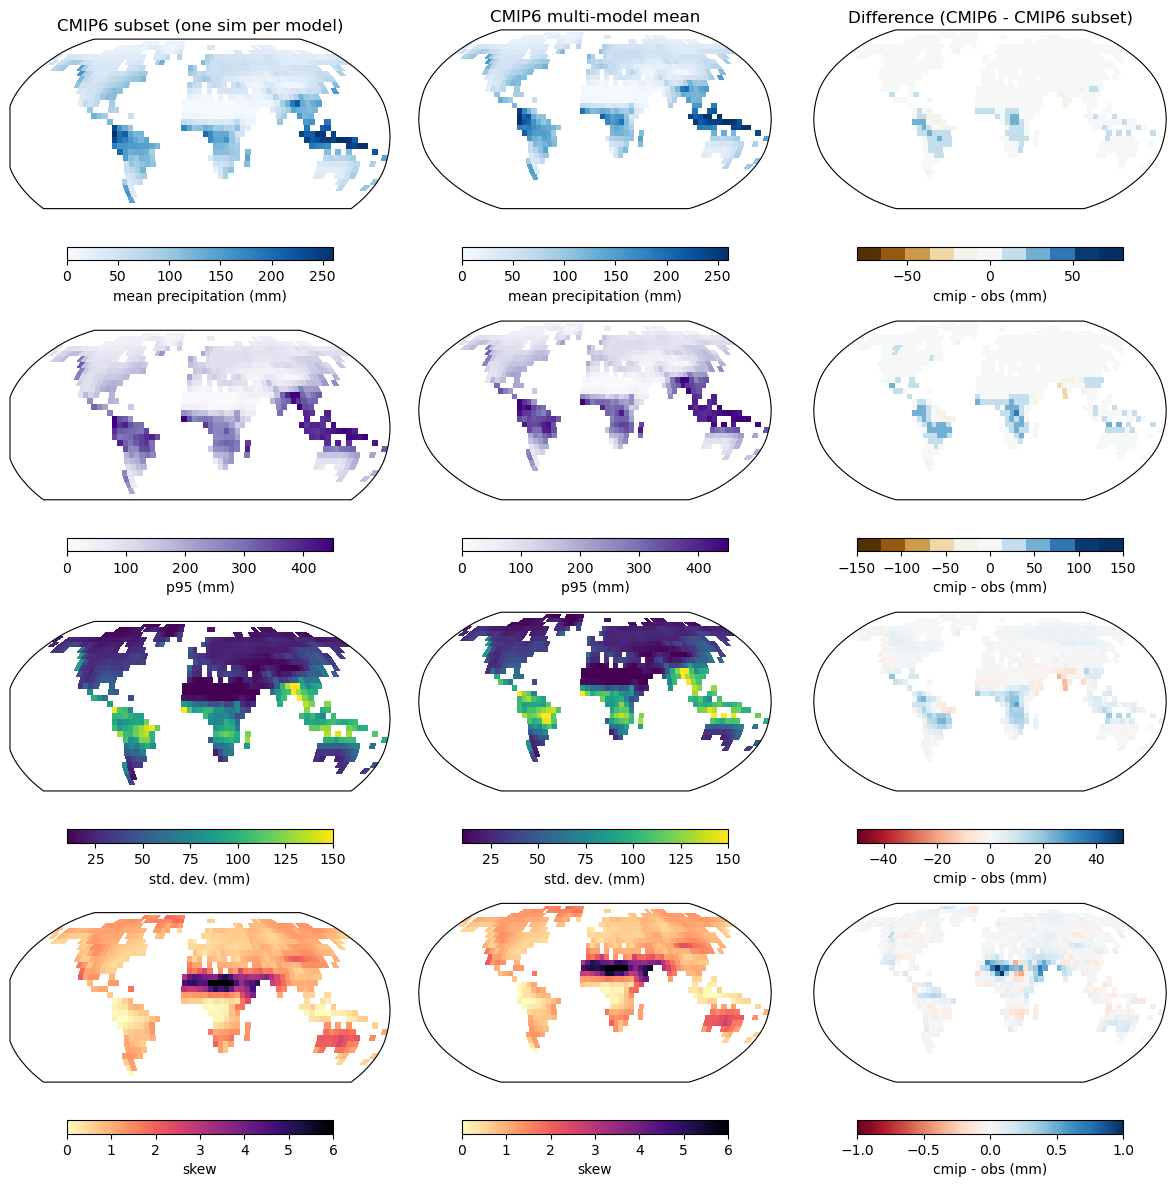

In [32]:
fig, axes = plt.subplots(4, 3, figsize = (12, 12), subplot_kw={"projection": ccrs.Robinson()})

## row 1
a = axes[0,0].pcolormesh(cmip_sub.lon, cmip_sub.lat, cmip_sub.mu.mean(dim = "model_variant")*86400*30, 
                         transform = ccrs.PlateCarree(), vmin = 0, vmax = 260, cmap = "Blues")
b = axes[0,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.mu.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 260, cmap = "Blues")
c = axes[0,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.mu.mean(dim = "model_variant")*86400*30 - cmip_sub.sel(lat = cmip_stat.lat).mu.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), cmap = brbl, vmin = -80, vmax = 80)
axes[0,1].set_global()
axes[0,2].set_global()
plt.colorbar(a, ax = axes[0,0], shrink = 0.7, location = "bottom", label = "mean precipitation (mm)")
plt.colorbar(b, ax = axes[0,1], shrink = 0.7, location = "bottom", label = "mean precipitation (mm)")
plt.colorbar(c, ax = axes[0,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 2
a = axes[1,0].pcolormesh(cmip_sub.lon, cmip_sub.lat, cmip_sub.p95.mean(dim = "model_variant")*86400*30, 
                         transform = ccrs.PlateCarree(), vmin = 0, vmax = 450, cmap = "Purples")
b = axes[1,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.p95.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 450, cmap = "Purples")
c = axes[1,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.p95.mean(dim = "model_variant")*86400*30 - cmip_sub.sel(lat = cmip_stat.lat).p95.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), cmap = brbl, vmin = -150, vmax = 150)
axes[1,1].set_global()
axes[1,2].set_global()
plt.colorbar(a, ax = axes[1,0], shrink = 0.7, location = "bottom", label = "p95 (mm)")
plt.colorbar(b, ax = axes[1,1], shrink = 0.7, location = "bottom", label = "p95 (mm)")
plt.colorbar(c, ax = axes[1,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 3
a = axes[2,0].pcolormesh(cmip_sub.lon, cmip_sub.lat, cmip_sub.sd.mean(dim = "model_variant")*86400*30, 
                         transform = ccrs.PlateCarree(), vmin = 10, vmax = 150)
b = axes[2,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.sd.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), vmin = 10, vmax = 150)
c = axes[2,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.sd.mean(dim = "model_variant")*86400*30 - cmip_sub.sel(lat = cmip_stat.lat).sd.mean(dim = "model_variant")*86400*30, 
                    transform = ccrs.PlateCarree(), cmap = "RdBu", vmin = -50, vmax = 50)
axes[2,1].set_global()
axes[2,2].set_global()
plt.colorbar(a, ax = axes[2,0], shrink = 0.7, location = "bottom", label = "std. dev. (mm)")
plt.colorbar(b, ax = axes[2,1], shrink = 0.7, location = "bottom", label = "std. dev. (mm)")
plt.colorbar(c, ax = axes[2,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

## row 4
a = axes[3,0].pcolormesh(cmip_sub.lon, cmip_sub.lat, cmip_sub.skew.mean(dim = "model_variant"), transform = ccrs.PlateCarree(), vmin = 0, vmax = 6, cmap = "magma_r")
b = axes[3,1].pcolormesh(cmip_stat.lon, cmip_stat.lat, cmip_stat.skew.mean(dim = "model_variant"), 
                    transform = ccrs.PlateCarree(), vmin = 0, vmax = 6, cmap = "magma_r")
c = axes[3,2].pcolormesh(cmip_stat.lon, cmip_stat.lat, 
                         cmip_stat.skew.mean(dim = "model_variant") - cmip_sub.sel(lat = cmip_stat.lat).skew.mean(dim = "model_variant"), 
                    transform = ccrs.PlateCarree(), cmap = "RdBu", vmin = -1, vmax = 1)
axes[3,1].set_global()
axes[3,2].set_global()
plt.colorbar(a, ax = axes[3,0], shrink = 0.7, location = "bottom", label = "skew")
plt.colorbar(b, ax = axes[3,1], shrink = 0.7, location = "bottom", label = "skew")
plt.colorbar(c, ax = axes[3,2], shrink = 0.7, location = "bottom", label = "cmip - obs (mm)")

axes[0,0].set(title = "CMIP6 subset (one sim per model)")
axes[0,1].set(title = "CMIP6 multi-model mean")
axes[0,2].set(title = "Difference (CMIP6 - CMIP6 subset)")
plt.tight_layout()

### ecdf comparison of obs and cmip

In [20]:
from statsmodels.distributions.empirical_distribution import ECDF

In [21]:
def ecdf_func(cmip, obs):
    if np.isnan(cmip).all():
        return(np.nan)
    return (ECDF(cmip)(obs))

def ecdf_xr(cmip, obs):       
    return xr.apply_ufunc(ecdf_func, cmip, obs, 
                          input_core_dims = (["model_variant"], []), 
                          dask = "allowed", 
                          vectorize = True, ## required when function can only take 1D array
                         )

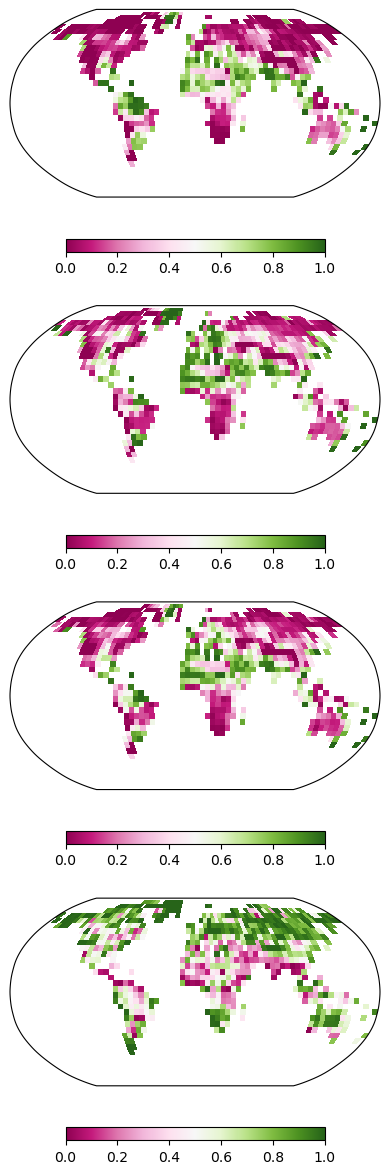

In [43]:
fig, axes = plt.subplots(4, 1, figsize = (4, 12), subplot_kw={"projection": ccrs.Robinson()})

## row 1
a = axes[0].pcolormesh(sd.lon, cmip_stat.lat, ecdf_xr(cmip_stat.mu*86400*30, sd.sel(lat = cmip_stat.lat).mu), 
                       transform = ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap = "PiYG")
plt.colorbar(a, ax = axes[0], shrink = 0.7, location = "bottom")
axes[0].set_global()

a = axes[1].pcolormesh(sd.lon, cmip_stat.lat, ecdf_xr(cmip_stat.sd*86400*30, sd.sel(lat = cmip_stat.lat).sd), 
                       transform = ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap = "PiYG")
plt.colorbar(a, ax = axes[1], shrink = 0.7, location = "bottom")
axes[1].set_global()

a = axes[2].pcolormesh(sd.lon, cmip_stat.lat, ecdf_xr(cmip_stat.p95*86400*30, sd.sel(lat = cmip_stat.lat).p95), 
                       transform = ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap = "PiYG")
plt.colorbar(a, ax = axes[2], shrink = 0.7, location = "bottom")
axes[2].set_global()

a = axes[3].pcolormesh(sd.lon, cmip_stat.lat, ecdf_xr(cmip_stat.skew, sd.sel(lat = cmip_stat.lat).skew), 
                       transform = ccrs.PlateCarree(), vmin = 0, vmax = 1, cmap = "PiYG")
plt.colorbar(a, ax = axes[3], shrink = 0.7, location = "bottom")
axes[3].set_global()

plt.tight_layout()

In [33]:
la = 35
lo = 250

In [40]:
sd.sel(lat = la, lon = lo, method = "nearest").p95.values

array(60.274933, dtype=float32)

(array([ 26.,  47.,  88., 122.,  61.,  20.,  12.,  10.,   0.,   4.]),
 array([ 60.58823395,  69.41053772,  78.23284149,  87.05514526,
         95.87745667, 104.69975281, 113.52206421, 122.34436798,
        131.16667175, 139.98898315, 148.8112793 ]),
 <BarContainer object of 10 artists>)

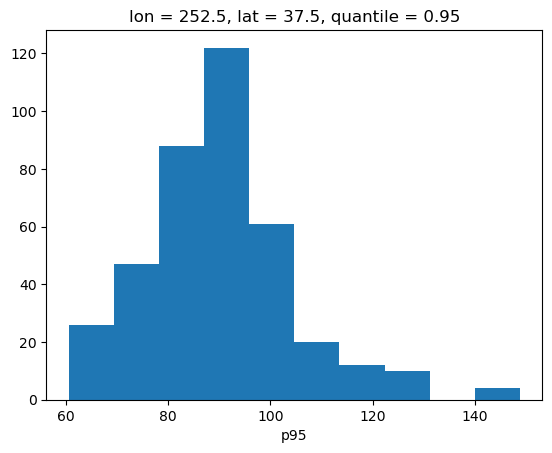

In [41]:
(cmip_stat.sel(lat = la, lon = lo, method = "nearest").p95*86400*30).plot.hist()